In [44]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    roc_auc_score
)
from xgboost import XGBClassifier
print('Bibliotecas importadas!')

Bibliotecas importadas!


In [45]:
def carregar_csv(nome_arquivo = 'flights_delays_120 1.csv'):
  if(os.path.exists(nome_arquivo)):
    print(f"Arquivo '{nome_arquivo}' encontrado. Carregando...")
    return pd.read_csv(nome_arquivo)
  else:
    print(f"Arquivo {nome_arquivo} não encontrado.")
    raise FileNotFoundError(f"Arquivo {nome_arquivo} não encontrado.")

def coluna_alvo(dados):
  candidatos = ["delayed", "atrasos", "alvo", "target", "y"]
  for c in candidatos:
    if c in dados.columns:
      print(f"Coluna alvo detectada: '{c}'.")
      return c

  print("Nenhuma coluna alvo encontrada.")
  raise KeyError("Nenhuma coluna alvo encontrada.")

In [46]:
dados = carregar_csv()
alvo = coluna_alvo(dados)

y = dados[alvo]
x = dados.drop(columns=[alvo])

cat = [c for c in x.columns if x[c].dtype == "object"]
num = [c for c in x.columns if c not in cat]

print(f"Colunas categóricas identificadas: {cat}")
print(f"Colunas numéricas identificadas: {num}")

from sklearn.model_selection import train_test_split

x_temp, x_teste, y_temp, y_teste = train_test_split(
    x, y,
    test_size=0.20,
    stratify=y,
    random_state=7
)

x_treino, x_val, y_treino, y_val = train_test_split(
    x_temp, y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=7
)

print(f"Dados divididos: {len(y_treino)} para treino, {len(y_val)} para validação e {len(y_teste)} para teste.")

Arquivo 'flights_delays_120 1.csv' encontrado. Carregando...
Coluna alvo detectada: 'delayed'.
Colunas categóricas identificadas: ['airline', 'origin', 'destination', 'weather']
Colunas numéricas identificadas: ['departure_hour', 'day_of_week']
Dados divididos: 72 para treino, 24 para validação e 24 para teste.


In [47]:
preprocessador = ColumnTransformer([
    ("categoricas", OneHotEncoder(handle_unknown="ignore"), cat),
    ("numericas", "passthrough", num)
])

modelo = XGBClassifier(
    n_estimators=300,
    learning_rate=0.08,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=7
)

pipeline = Pipeline([
    ("prep", preprocessador),
    ("xgb", modelo)
])

In [48]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'xgb__n_estimators': [100, 300, 500],
    'xgb__learning_rate': [0.01, 0.08, 0.1],
    'xgb__max_depth': [3, 6, 9]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    verbose=1,
    n_jobs=-1
)

print("Iniciando a busca pelos melhores hiperparâmetros...")
grid_search.fit(x_treino, y_treino)

print(f"\nMelhores hiperparâmetros encontrados: {grid_search.best_params_}")

melhor_modelo = grid_search.best_estimator_

y_val_pred = melhor_modelo.predict(x_val)
print("\nDesempenho no conjunto de VALIDAÇÃO:")
print(classification_report(y_val, y_val_pred))

Iniciando a busca pelos melhores hiperparâmetros...
Fitting 3 folds for each of 27 candidates, totalling 81 fits

Melhores hiperparâmetros encontrados: {'xgb__learning_rate': 0.01, 'xgb__max_depth': 6, 'xgb__n_estimators': 300}

Desempenho no conjunto de VALIDAÇÃO:
              precision    recall  f1-score   support

           0       0.92      0.85      0.88        13
           1       0.83      0.91      0.87        11

    accuracy                           0.88        24
   macro avg       0.88      0.88      0.87        24
weighted avg       0.88      0.88      0.88        24



In [49]:
probas = melhor_modelo.predict_proba(x_teste)[:,1]

threshold = 0.5

y_pred = (probas >= threshold).astype(int)

cm = confusion_matrix(y_teste, y_pred)

print("Métricas de Desempenho (Threshold 0.5)")
print("Matriz de Confusão:\n", cm)

print(f"Acurácia: {accuracy_score(y_teste, y_pred):.4f}")

print(f"Precisão: {precision_score(y_teste, y_pred, zero_division=0):.4f}")

print(f"Recall (Sensibilidade): {recall_score(y_teste, y_pred, zero_division=0):.4f}")

print(f"F1-Score: {f1_score(y_teste, y_pred, zero_division=0):.4f}")

print("\nRelatório de Classificação:\n", classification_report(y_teste, y_pred))

Métricas de Desempenho (Threshold 0.5)
Matriz de Confusão:
 [[14  0]
 [ 0 10]]
Acurácia: 1.0000
Precisão: 1.0000
Recall (Sensibilidade): 1.0000
F1-Score: 1.0000

Relatório de Classificação:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        10

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24




Curva ROC
AUC (Área Sob Curva): 1.0000


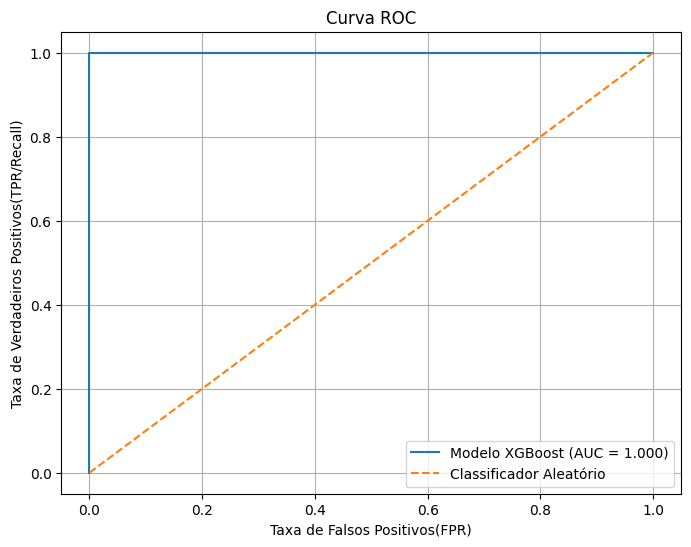

In [50]:
fpr, tpr, thresholds = roc_curve(y_teste, probas)
auc = roc_auc_score(y_teste, probas)

print("\nCurva ROC")
print(f"AUC (Área Sob Curva): {auc:.4f}")

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"Modelo XGBoost (AUC = {auc:.3f})")
plt.plot([0,1],[0,1], linestyle="--", label="Classificador Aleatório")
plt.xlabel("Taxa de Falsos Positivos(FPR)")
plt.ylabel("Taxa de Verdadeiros Positivos(TPR/Recall)")
plt.title("Curva ROC")
plt.legend()
plt.grid(True)
plt.show()

In [51]:
import pandas as pd

novos_voos = pd.DataFrame({
    'airline': ['DL', 'AA', 'B6'],
    'origin': ['ATL', 'JFK', 'MCO'],
    'destination': ['LAX', 'MIA', 'BOS'],
    'weather': ['clear', 'cloudy', 'rain'],
    'departure_hour': [8, 14, 22],
    'day_of_week': [2, 5, 7]
})

print("Novos voos a serem avaliados:")
display(novos_voos)

previsoes = melhor_modelo.predict(novos_voos)
probabilidades = melhor_modelo.predict_proba(novos_voos)[:, 1]

novos_voos['vai_atrasar'] = previsoes
novos_voos['probabilidade_atraso (%)'] = (probabilidades * 100).round(2)

print("\nResultados da Inferência (0 = No Horário, 1 = Atrasado):")
display(novos_voos)

Novos voos a serem avaliados:


,airline,origin,destination,weather,departure_hour,day_of_week
0,DL,ATL,LAX,clear,8,2
1,AA,JFK,MIA,cloudy,14,5
2,B6,MCO,BOS,rain,22,7



Resultados da Inferência (0 = No Horário, 1 = Atrasado):


,airline,origin,destination,weather,departure_hour,day_of_week,vai_atrasar,probabilidade_atraso (%)
0,DL,ATL,LAX,clear,8,2,0,31.400000
1,AA,JFK,MIA,cloudy,14,5,1,82.669998
2,B6,MCO,BOS,rain,22,7,1,81.199997
